# 第 8 章 无监督学习：聚类与降维

无监督学习的特点：**没有标签**，算法只能靠数据本身的结构去“自己找规律”。本章主要看两件事：

* 把样本自动**分组** → 聚类
* 在不丢太多信息的前提下**压缩特征维度** → 降维（SVD / PCA）

## 8.1 聚类

### 8.1.1 聚类简介

**聚类（Clustering）**：把数据集中的样本分成若干个“簇（cluster）”，要求：

* **同一簇内**：样本彼此相似
* **不同簇之间**：差异尽量大

聚类是典型的**无监督学习**：
没有“真标签”，完全根据样本之间的**相似性/距离**来自动分组。最后每个簇具体代表什么含义，通常要由**人来理解和命名**。

#### 聚类的一般步骤

1. **定义相似性 / 距离**

   常见做法：

   * 欧氏距离：
     $$
     d(x_i, x_j) = \lVert x_i - x_j \rVert
     $$
   * 余弦相似度：适合文本、方向性特征
     $$
     \text{sim}(x_i, x_j) = \frac{x_i^\top x_j}{\lVert x_i \rVert , \lVert x_j \rVert}
     $$

2. **分组**

   根据距离/相似性，把样本分到不同簇中。

3. **优化**

   通过迭代更新簇的划分，使：

   * **簇内更紧凑**（相似度高）
   * **簇间更分离**（差异大）

#### 聚类的典型应用

* **市场细分**：把用户按消费习惯、浏览行为分组
* **图像分割**：按颜色、纹理把图像像素分块
* **异常检测**：远离任何主要簇的点，可以看作异常
* **生物信息学**：基因表达数据分组，发现功能相近的基因

> 一句话：聚类就是让“物以类聚、人以群分”自动发生。

### 8.1.2 常见聚类算法

#### 1）K-means 聚类

##### （1）基本思想

给定一个样本集合 ${x_1, \dots, x_n}$，K-means 要做的事：

* 把样本分成 **$K$ 个簇** $C_1, \dots, C_K$
* 每个簇有一个**簇中心（均值）** $\mu_k$
* 让样本到其所属簇中心的**距离平方和最小**

常用的目标函数（损失函数）是：

$$
\min_{{C_k},{\mu_k}} \sum_{k=1}^K \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

这里：

* $C_k$：第 $k$ 个簇包含的样本集合
* $\mu_k$：第 $k$ 个簇的中心（即该簇样本的均值）

> 每个样本**只能属于 1 个簇**，这种叫 **硬聚类（hard clustering）**。

严格求这个最小值是一个复杂的组合优化问题，实际中我们用一个简单的**迭代算法**来近似求解。

##### （2）K-means 的工作流程

1. **初始化**

   随机选择 $K$ 个样本作为初始簇中心 $\mu_1, \dots, \mu_K$。

2. **分配样本到最近簇**

   对每个样本 $x_i$，计算它到所有簇中心的距离，把它分配到**最近的那个簇**：

   $$
   x_i \in C_k \quad \text{if} \quad k = \arg\min_j \lVert x_i - \mu_j \rVert
   $$

3. **更新簇中心**

   对每个簇 $C_k$，重新计算中心为簇内样本的均值：

   $$
   \mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i
   $$

4. **重复 2–3 步**

   直到：

   * 簇划分不再变化，或者
   * 达到最大迭代次数，或者
   * 损失函数下降很小

##### （3）K-means 的特点

**优点：**

* 实现简单，收敛快
* 对“球形”“大小差不多”的簇效果不错

**缺点：**

* 需要**事先指定簇数 $K$**
* 对**初始中心敏感**，容易陷入局部最优
* 只能很好处理**凸形状簇**，对复杂形状（如“月牙形”）不友好
* 对噪声点和异常值敏感

常见做法是尝试不同的 $K$，用一些指标（如簇内平方和、轮廓系数等）评估结果，选一个比较合适的 $K$，这部分见 8.1.4。

**应用场景：**
当你大致知道“应该有几个类别”，又希望快速把样本分成几团时，用 K-means 很合适。

#### 2）层次聚类（Hierarchical Clustering）

层次聚类假设簇之间有**层级结构**（像一棵树），通过不断**合并**或**分裂**簇来构建这种结构。

> 特点：每个样本仍然只属于一个簇 → 也是硬聚类。

##### （1）自下而上：聚合聚类（Agglomerative）

流程：

1. 一开始，每个样本单独成簇（有 $n$ 个簇）
2. 每次找到**距离最近的两个簇**，把它们合并
3. 重复合并，直到：

   * 达到预设簇数，或
   * 簇内相似性达到某个阈值，或
   * 只剩一个大簇

效果就像“从叶子往上合并成树的过程”。

##### （2）自上而下：分裂聚类（Divisive）

流程：

1. 一开始，所有样本在一个大簇中
2. 每次选择一个“内部差异较大”的簇，把它**分成两个子簇**
3. 重复分裂，直到：

   * 达到预设簇数，或
   * 每个簇足够紧凑

**应用场景：**
当你希望看到“从粗到细”的分组结构（比如企业组织结构、物种分类），层次聚类能给出一个很直观的**树状图（dendrogram）**。

#### 3）密度聚类（以 DBSCAN 为例）

密度聚类的基本假设：

> 聚类结构可以通过“**样本分布的密集区域**”来确定。

常见算法：**DBSCAN**。

给定数据集 $D = {x_1, x_2, \dots, x_m}$，DBSCAN 依赖两个参数：

* $\varepsilon$：邻域半径（eps）
* MinPts：一个点如果邻域内样本数 ≥ MinPts，就算“密集”

##### 核心概念（通俗版）

* **$\varepsilon$-邻域**：
  对于样本 $x_i$，它的 $\varepsilon$-邻域是所有与它距离不超过 $\varepsilon$ 的样本集合。

* **核心对象（core point）**：
  如果 $x_i$ 的 $\varepsilon$-邻域里至少有 MinPts 个样本，则 $x_i$ 是核心对象。

* **密度直达（directly density-reachable）**：
  如果 $x_j$ 在 $x_i$ 的 $\varepsilon$-邻域内，并且 $x_i$ 是核心对象，则 $x_j$ 由 $x_i$ 密度直达。

* **密度可达（density-reachable）**：
  如果存在点列 $p_1, \dots, p_n$，使得：

  * $p_1 = x_i, ; p_n = x_j$
  * 对所有 $k$，$p_{k+1}$ 由 $p_k$ 密度直达
    那么称 $x_j$ 由 $x_i$ 密度可达。

* **密度相连（density-connected）**：
  如果存在一个点 $x_k$，使得 $x_i$ 和 $x_j$ 都由 $x_k$ 密度可达，则称 $x_i$ 和 $x_j$ 密度相连。

* **噪声点**：
  既不是核心点，又不在任何核心点邻域中的点。

##### DBSCAN 的簇定义和流程

* **簇**：由“密度可达”关系扩展出的**最大密度相连样本集合**。
* 大致流程：

  1. 根据 $(\varepsilon,\text{MinPts})$ 找出所有核心点
  2. 从某个核心点开始，通过“密度直达/密度可达”往外扩展，形成一个簇
  3. 重复上一步，直到所有核心点都处理完

##### DBSCAN 的特点

**优点：**

* 能识别**任意形状**的簇（例如“环形”“月牙形”）
* 可以自动识别并排除**噪声点**
* 不需要预先指定簇数

**缺点：**

* 对参数 $\varepsilon$ 和 MinPts **敏感**
* 当数据的密度变化很大时，难以兼顾所有区域

**应用场景：**
想在带噪声的数据中找到“密集区域”，而且簇的形状可能很复杂时，用 DBSCAN 是不错的选择。

### 8.1.3 K-means 在 sklearn 中的使用

在 `scikit-learn` 中，K-means 的典型用法如下：

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
# n_clusters: 指定 K 的值

kmeans.fit(X)          # 训练，只拟合模型
labels = kmeans.predict(X)      # 对 X 中的样本进行聚类预测
labels2 = kmeans.fit_predict(X) # 一次性完成训练 + 预测

* `kmeans.cluster_centers_`：返回每个簇的中心坐标
* `kmeans.inertia_`：簇内平方和（后面评估会用到）

#### 示例：用 K-means 聚类二维数据

findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because

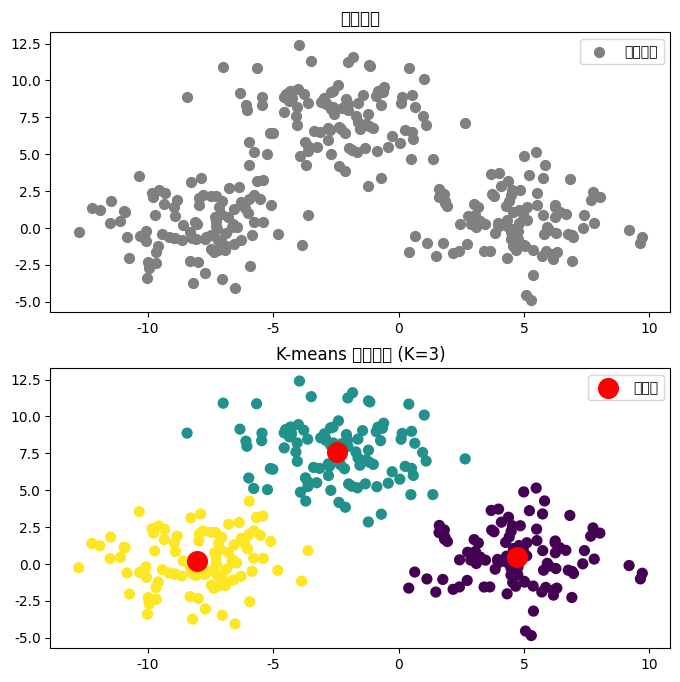

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

plt.rcParams["font.sans-serif"] = ["KaiTi"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 生成 3 个簇，每个簇 100 个点
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=2)

fig, ax = plt.subplots(2, figsize=(8, 8))

# 原始数据
ax[0].scatter(X[:, 0], X[:, 1], s=50, c="gray", label="原始数据")
ax[0].set_title("原始数据")
ax[0].legend()

# 2. 使用 K-Means 聚类
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)         # 每个点的簇标签
centers = kmeans.cluster_centers_    # 簇中心

# 3. 绘制聚类结果
ax[1].scatter(X[:, 0], X[:, 1], s=50, c=y_kmeans)
ax[1].scatter(centers[:, 0], centers[:, 1],
              s=200, c="red", marker="o", label="簇中心")
ax[1].set_title("K-means 聚类结果 (K=3)")
ax[1].legend()

plt.show()

**说明：**

* 第一幅图：原始点云，没有任何标记
* 第二幅图：

  * 不同颜色代表 K-means 分出来的 3 个簇
  * 红色大圆点是每个簇的**中心**

**应用场景：**
这种可视化方式非常适合用来**直观理解 K-means 的效果**，以及调试不同的 $K$、不同的特征标准化方法等。

### 8.1.4 聚类模型评估（了解）

聚类和分类最大的不同：**没有真实标签**。
所以我们不能直接算“准确率”，而是要根据：

* 簇内是否够紧（**紧凑性**）
* 簇间是否够远（**分离性**）

来衡量聚类效果。

常见指标：

1. 轮廓系数（Silhouette Coefficient）
2. 簇内平方和（Within-Cluster Sum of Squares, WCSS）
3. 肘部法（Elbow Method）
4. CH 指数（Calinski-Harabasz Index）

#### 1）轮廓系数（Silhouette Coefficient）

对每个样本 $i$：

* $a_i$：样本 $i$ 到**同簇其他样本**的平均距离（簇内距离）
* $b_i$：样本 $i$ 到**最近的其他簇**中样本的平均距离（最近“邻居簇”的距离）

轮廓系数定义为：

$$
s_i = \frac{b_i - a_i}{\max(a_i, b_i)}, \quad s_i \in [-1, 1]
$$

直观解释：

* $s_i$ 接近 **1**：
  簇内距离小（$a_i$ 小），到其他簇距离大（$b_i$ 大），**聚得很好**
* $s_i$ 接近 **0**：
  处在两个簇边界附近
* $s_i$ 为 **负数**：
  更“像”其他簇 → 可能被分错

**总体轮廓系数**是所有样本 $s_i$ 的平均值，用来描述整体聚类质量。

#### 2）簇内平方和（Within-Cluster Sum of Squares, WCSS）

主要用于 K-means：

$$
\text{WCSS} = \sum_{k=1}^K \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

* $C_k$：第 $k$ 个簇
* $\mu_k$：第 $k$ 个簇的中心

在 `sklearn` 的 KMeans 中，这个值就保存在：

In [ ]:
kmeans.inertia_  # 就是 WCSS

**直观理解**：聚得越紧，WCSS 越小。

#### 3）肘部法（Elbow Method）

目标：**帮助选择合适的簇数 $K$**。

做法：

1. 尝试多个不同的 $K$（例如 1 到 10）
2. 对每个 $K$，运行 K-means，记录对应的 WCSS
3. 画出 “$K$–WCSS” 曲线

通常会看到：

* $K$ 小时，增加 $K$ 会让 WCSS 快速下降
* 过了某个 $K$，继续增加 $K$，WCSS 下降幅度明显变小
  → 曲线出现一个“拐点”，很像手肘

这个拐点对应的 $K$，通常被认为是“**比较合适的簇数**”。

#### 4）CH 指数（Calinski-Harabasz Index）

CH 指数又叫 **方差比准则**，是“簇间分散度”与“簇内分散度”的比值。

定义：

$$
\text{CH} =
\frac{\text{BCSS} / (K - 1)}
{\text{WCSS} / (N - K)}
$$

* $N$：样本总数
* $K$：簇数
* WCSS：簇内平方和
* BCSS：簇间平方和，衡量簇中心间差异

其中：

$$
\text{WCSS} = \sum_{k=1}^K \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2
$$

$$
\text{BCSS} = \sum_{k=1}^K n_k \lVert \mu_k - \mu \rVert^2
$$

* $n_k$：第 $k$ 个簇的样本数
* $\mu_k$：第 $k$ 个簇的中心
* $\mu$：所有样本的整体中心

**CH 越大，一般说明簇间分离越好、簇内越紧凑。**

#### 5）聚类评估 API 示例

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/Users/shenjiuyang/workspace/llm-learning/.ven

簇内平方和 (WCSS)： 8863.977786511434
平均轮廓系数： 0.3904139531599418
CH 指数： 235.37170952519992


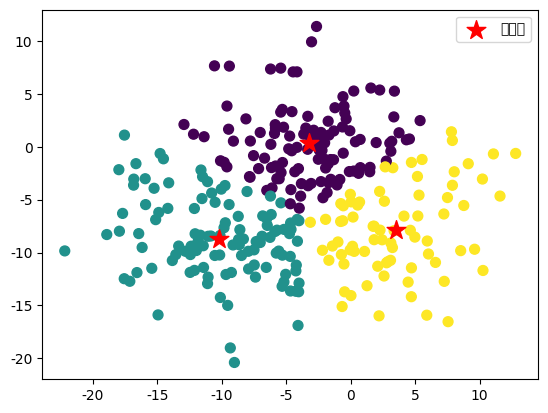

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, calinski_harabasz_score

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 生成 3 个簇，每个簇 100 个点
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=5)

# 2. 使用 K-Means 聚类
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

# 3. 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], s=50, c=y_kmeans)
plt.scatter(centers[:, 0], centers[:, 1],
            s=200, c="red", marker="*", label="簇中心")
plt.legend()

# 4. 打印评估指标
print("簇内平方和 (WCSS)：", kmeans.inertia_)
print("平均轮廓系数：", silhouette_score(X, y_kmeans))
print("CH 指数：", calinski_harabasz_score(X, y_kmeans))

plt.show()

**说明：**

* `kmeans.inertia_`：你可以用它随 $K$ 变化画肘部图
* `silhouette_score`：整体轮廓系数，越接近 1 越好
* `calinski_harabasz_score`：CH 指数，值越大越好

**应用场景：**
这些指标帮你在“不同聚类参数/不同算法之间”做选择，而不是凭感觉看图。

## 8.2 降维（了解）

降维的目标：

> 在**尽量保留信息**的前提下，用**更少的特征**来表示数据。

好处：

* 可视化（2D/3D）
* 减少噪声，提升模型泛化能力
* 降低计算成本

本节主要看两个概念：

* 奇异值分解（SVD）：一种矩阵分解工具
* 主成分分析（PCA）：一个经典的降维方法，通常基于 SVD 实现

### 8.2.1 奇异值分解（SVD）

#### （1）SVD 简介

对任意一个实矩阵 $A \in \mathbb{R}^{n \times p}$，奇异值分解是把它写成三个矩阵的乘积：

$$
A = U \Sigma V^\top
$$

* $U$：$n \times n$ 的**正交矩阵**，$U^\top U = I$
* $V$：$p \times p$ 的**正交矩阵**，$V^\top V = I$
* $\Sigma$：$n \times p$ 的“**对角矩阵**”，对角线上是**奇异值** $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_p \ge 0$

对 $A$ 的解释：

* $V$：原特征空间里的**一组正交基向量**
* $\Sigma$：沿这些方向的“拉伸强度”（奇异值越大，方向越重要）
* $U$：把结果映射回样本空间

> 通俗理解：SVD 就是把矩阵拆成“**旋转 → 缩放 → 再旋转**”。

SVD 常用于：

* 低秩近似（压缩 / 去噪）
* 推荐系统（潜在语义分析）
* PCA（下一节）

#### （2）通过特征值分解求 SVD（原理了解）

数学上，SVD 可以通过对称矩阵 $A^\top A$ 的特征分解得到：

1. 求解特征值问题：
   $$
   (A^\top A - \lambda I)x = 0
   $$
2. 令 $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p \ge 0$ 为特征值，对应的单位特征向量为 $v_1, \dots, v_p$，组成矩阵：
   $$
   V = [v_1, v_2, \dots, v_p]
   $$
3. 奇异值为：
   $$
   \sigma_i = \sqrt{\lambda_i}
   $$
   形成对角矩阵：
   $$
   \Sigma = \text{diag}(\sigma_1, \dots, \sigma_p)
   $$
4. 对每个正奇异值，用公式求 $U$ 的列向量：
   $$
   u_i = \frac{1}{\sigma_i} A v_i
   $$

> 实际中我们**不会手算 SVD**，而是调用数值库（如 NumPy / SciPy），以上过程只用于理解原理。

#### （3）SVD 与低秩近似（和降维的关系）

如果只保留前 $r$ 个最大的奇异值及其对应的奇异向量：

$$
A \approx U_r \Sigma_r V_r^\top
$$

* $r \ll \min(n, p)$
* 这相当于用一个**秩为 $r$ 的矩阵**来近似 $A$

效果：

* 丢掉了较小奇异值对应的“细节/噪声”
* 保留了主要结构信息
* 维度和存储量都大幅减少

> 这就是 SVD 用来“压缩信息”和“辅助降维”的原因。

### 8.2.2 主成分分析（PCA）

#### （1）PCA 简介

**主成分分析（Principal Component Analysis, PCA）**是一种常用的无监督降维方法。

目标：

> 找到一组新的正交坐标轴（主成分），
> 让数据在这些轴上的**方差尽可能大**，并且只保留前几个“最重要的方向”。

特点：

* 主成分彼此正交（线性无关）
* 第一主成分：方差最大的方向
* 第二主成分：在与第一主成分正交的前提下，方差最大
* …

常见用途：

* 降维（比如从 100 维压到 2 维）
* 消除特征之间的线性相关性
* 查看数据的“主要变化方向”（探索数据结构）

#### （2）PCA 的基本步骤

假设有样本矩阵 $X \in \mathbb{R}^{n \times p}$（$n$ 个样本，$p$ 个特征）。

1. **标准化**

   对每一列特征做零均值、单位方差处理：

   * 每列减去均值
   * 再除以标准差

2. **计算协方差矩阵**

   标准化后的数据记为 $X$，其协方差矩阵：

   $$
   S = \frac{1}{n-1} X^\top X
   $$

3. **特征值分解**

   对协方差矩阵做特征值分解：

   $$
   S = V \Lambda V^\top
   $$

   * $V$ 的列向量是特征向量 → **主成分方向**
   * $\Lambda$ 的对角元素是特征值 → 每个主成分的方差

4. **得到主成分表示**

   用前 $k$ 个特征向量组成 $V_k$：

   $$
   Y = X V_k
   $$

   * $Y$：降维后的数据（$n \times k$）
   * 每一列是一个主成分上的坐标

5. **方差贡献率**

   设特征值为 $\lambda_1 \ge \dots \ge \lambda_p$，
   第 $i$ 个主成分的方差贡献率为：

   $$
   \text{ratio}*i = \frac{\lambda_i}{\sum*{j=1}^p \lambda_j}
   $$

   可以根据累计贡献率（例如达到 90%）选择 $k$。

#### （3）用 SVD 实现 PCA（更常用）

在实际计算中，更常见的做法是直接对标准化后的 $X$ 做 SVD：

$$
X = U \Sigma V^\top
$$

则：

* $V$ 的列向量就是 PCA 的主成分方向
* 协方差矩阵可以写成：
  $$
  S = \frac{1}{n-1} X^\top X
  = \frac{1}{n-1} V \Sigma^\top \Sigma V^\top
  = V \Lambda V^\top
  $$
  其中：
  $$
  \Lambda = \frac{1}{n-1} \Sigma^\top \Sigma,\quad
  \lambda_i = \frac{\sigma_i^2}{n-1}
  $$
* 主成分表示为：
  $$
  Y = X V
  $$

> 总结：**SVD 直接给出了 PCA 需要的“方向”和“方差”**，因此很多库内部都是用 SVD 来做 PCA。

#### （4）简单的 PCA 代码示例（sklearn）

In [3]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X: shape (n_samples, n_features)
# 1. 标准化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 2. 保留前 2 个主成分
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("各主成分的方差贡献率：", pca.explained_variance_ratio_)
print("累积方差贡献率：", np.sum(pca.explained_variance_ratio_))

各主成分的方差贡献率： [0.55464411 0.44535589]
累积方差贡献率： 0.9999999999999998


**说明：**

* `X_pca`：降到 2 维后的数据，可以用于画散点图
* `explained_variance_ratio_`：每个主成分解释的方差比例
* 通过观察贡献率，可以决定要保留多少个主成分

**应用场景：**
当你的特征维度很高、其中很多特征高度相关，希望“**压缩维度 + 去掉冗余**”时，用 PCA 是一个非常实用的工具。